In [1]:
import torch
from torch import nn
import pandas as pd
import sys
from pathlib import Path

train_labels = pd.read_csv('../cifar-10/trainLabels.csv')
val_labels = pd.read_csv('../cifar-10/valLabels.csv')

sys.path.append(str(Path.cwd().parent))
torch.manual_seed(42)

In [2]:
from src.dataset import CIFAR10Dataset, train_transforms, val_transforms

train_dataset = CIFAR10Dataset(
    image_dir='../cifar-10/train',
    labels=train_labels,
    transform=train_transforms
)

val_dataset = CIFAR10Dataset(
    image_dir='../cifar-10/val',
    labels=val_labels,
    transform=val_transforms
)

In [3]:
from src.dataset import create_dataloader

train_loader = create_dataloader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = create_dataloader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False
)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [5]:
from src.models import CIFARDeeperCNN
from src.metrics import create_metrics
from src.engine import fit

model = CIFARDeeperCNN().to(device)

train_metrics = create_metrics(num_classes=10)
val_metrics = create_metrics(num_classes=10)

for metric in train_metrics.values():
    metric = metric.to(device)
for metric in val_metrics.values():
    metric = metric.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)
epochs = 30

history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_metrics=train_metrics,
    val_metrics=val_metrics,
    epochs=epochs,
    device=device,
    file_path='../models/CIFAR_Augmentation_WD_DeeperCNN.pt'
)

history


Epoch 1/30:
Training Loss: 1.8016 | Training Accuracy: 32.67% | Training Precision: 31.99% | Training Recall: 32.67%
Validation Loss: 1.5176 | Validation Accuracy: 42.80% | Validation Precision: 43.41% | Validation Recall: 42.80%
Best model saved! Val Acc: 42.80%

Epoch 2/30:
Training Loss: 1.4734 | Training Accuracy: 45.57% | Training Precision: 44.98% | Training Recall: 45.57%
Validation Loss: 1.3104 | Validation Accuracy: 51.44% | Validation Precision: 52.86% | Validation Recall: 51.44%
Best model saved! Val Acc: 51.44%

Epoch 3/30:
Training Loss: 1.3182 | Training Accuracy: 51.81% | Training Precision: 51.27% | Training Recall: 51.81%
Validation Loss: 1.1877 | Validation Accuracy: 56.46% | Validation Precision: 57.74% | Validation Recall: 56.46%
Best model saved! Val Acc: 56.46%

Epoch 4/30:
Training Loss: 1.1978 | Training Accuracy: 56.31% | Training Precision: 55.84% | Training Recall: 56.31%
Validation Loss: 1.1006 | Validation Accuracy: 60.26% | Validation Precision: 62.07% | 

,epoch,train_loss,train_accuracy,train_precision,train_recall,val_loss,val_accuracy,val_precision,val_recall
0,1,1.801596,0.326675,0.319887,0.326675,1.517580,0.4280,0.434147,0.4280
1,2,1.473373,0.455700,0.449838,0.455700,1.310375,0.5144,0.528589,0.5144
2,3,1.318247,0.518075,0.512671,0.518075,1.187694,0.5646,0.577443,0.5646
3,4,1.197751,0.563075,0.558423,0.563075,1.100644,0.6026,0.620744,0.6026
4,5,1.112415,0.600700,0.597399,0.600700,1.047078,0.6302,0.641410,0.6302
5,6,1.035586,0.632025,0.629035,0.632025,0.950411,0.6640,0.681169,0.6640
6,7,0.970069,0.652550,0.649851,0.652550,0.871037,0.6914,0.692608,0.6914
7,8,0.915210,0.676075,0.673924,0.676075,0.822929,0.7082,0.717931,0.7082
8,9,0.868977,0.691725,0.689961,0.691725,0.829332,0.7046,0.724140,0.7046
9,10,0.833512,0.704250,0.702595,0.704250,0.798914,0.7142,0.728044,0.7142


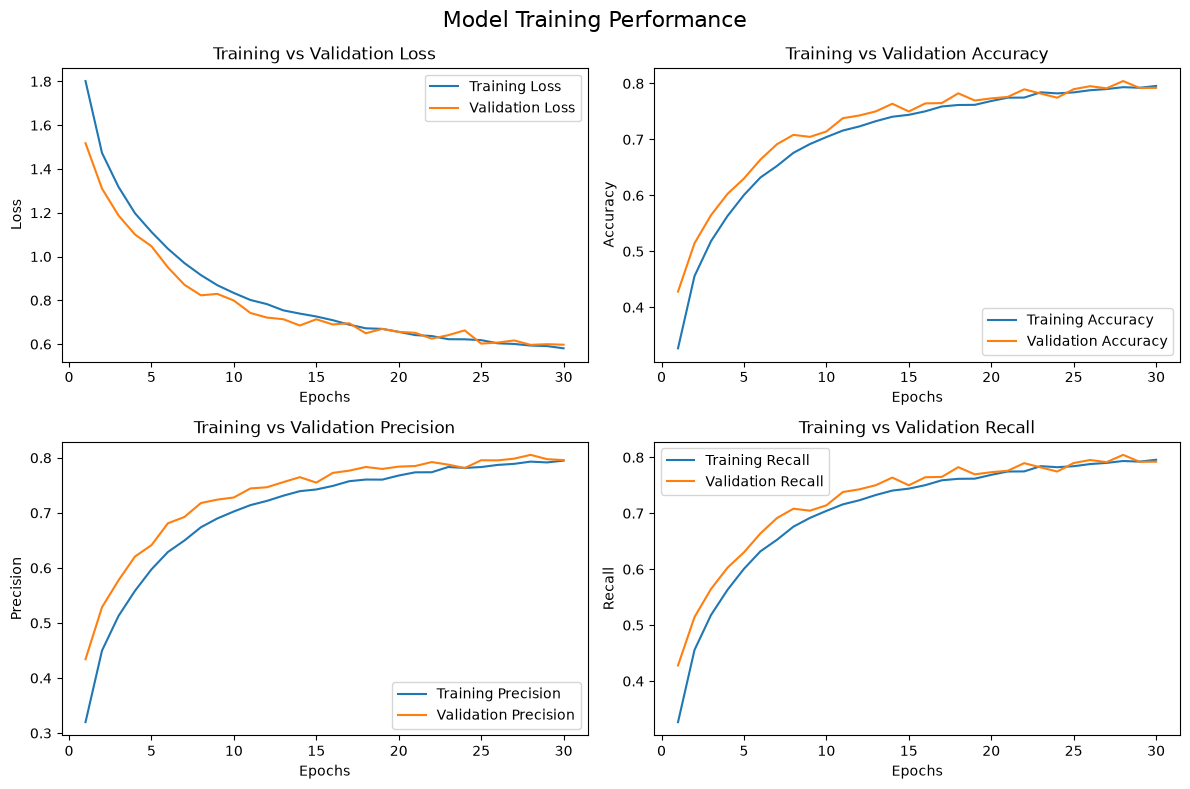

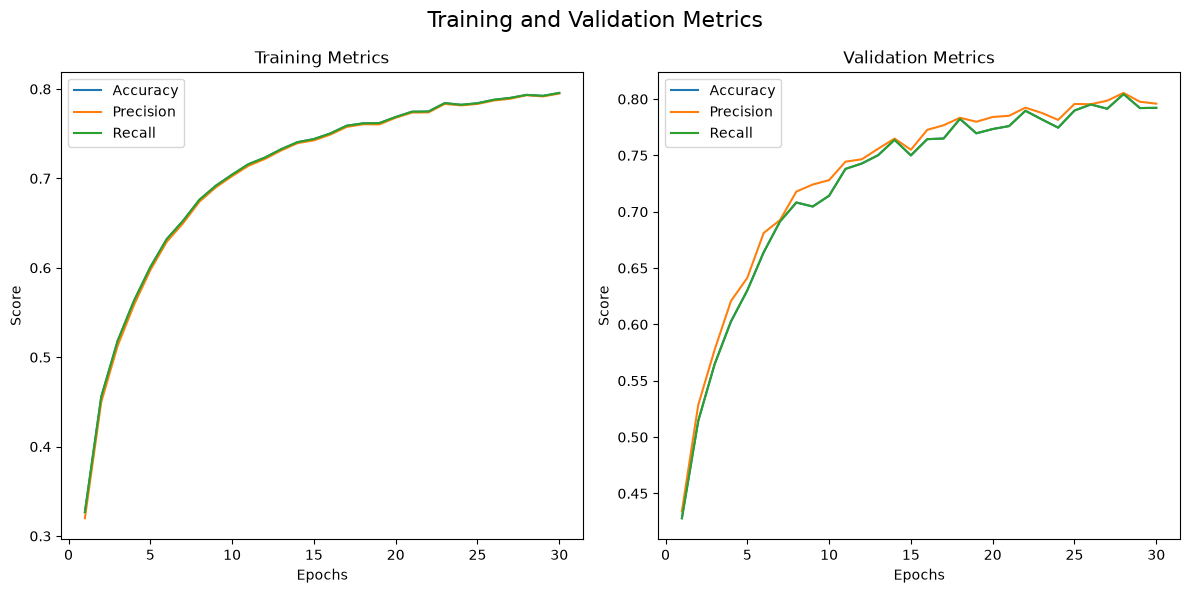

In [6]:
from src.plots import plot_all_metrics, plot_performance

plot_all_metrics(history=history)
plot_performance(history=history)